Taking our 12 m spacing and comparing speedup for Woodhouse Moor, but also comparing to output previously.

In [32]:
import pytest
import geopandas as gpd
import json
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt


sys.path.insert(0, '../../src')

import park_vga

import cProfile
import pstats

In [2]:
TEST_PARK_NAME = "Woodhouse Moor"

output_folder = "optimisation_test_output"

DATA_DIR = "../../example_datasets/"

dsm_path = "../../tests/test_data_england/DSM"
dtm_path = "../../tests/test_data_england/DTM"

boundaries_file = str(DATA_DIR + 'Leeds_pp_or_g_cmb.geojson')

In [3]:
park_n = park_vga.workflow.find_park_n(TEST_PARK_NAME, boundaries_file)

In [4]:
park_n

51

In [5]:
# profiler = cProfile.Profile()
# profiler.enable()

In [6]:
# results_1 = park_vga.workflow.workflow_eng(boundaries_file, park_n,
#                                          dtm_path, dsm_path,
#                                          output_folder,
#                                          return_results=True, save_results=False)

In [7]:
# profiler.disable()
# stats = pstats.Stats(profiler)
# stats.sort_stats('cumulative').print_stats(20)  # Top 20 functions by time

In [8]:
profiler = cProfile.Profile()
profiler.enable()

In [9]:
results_2 = park_vga.workflow.workflow_eng(boundaries_file, park_n,
                                         dtm_path, dsm_path,
                                         output_folder,
                                         spacing=12,
                                         return_results=True, save_results=False)

Output directory already exists at optimisation_test_output
Park ID: LEEDS_6ddbccbe638c;LEEDS_9866db1f86cb;LEEDS_5702a0af86e2
Park ID for file name: leeds_6ddbccbe638c;leeds_9866db1f86cb;leeds_5702a0af86e2
Define park grid.
Load park tiles
Finding tile names from park geometry
Calculating grid refs
[(429274.64295245457, 434705.6015645066), (429274.64295245457, 435442.7927353812), (428675.24753552524, 435442.7927353812), (428675.24753552524, 434705.6015645066)]
Grid refs for corners: ['SE23se', 'SE23ne', 'SE23ne', 'SE23se']
Tile name(s): {'SE23se', 'SE23ne'} 
Finding file paths for these tiles
Paths found: 
DTM paths: ['../../tests/test_data_england/DTM/SE23se_DTM_1m.tif', '../../tests/test_data_england/DTM/SE23ne_DTM_1m.tif'] 
DSM paths: ['../../tests/test_data_england/DSM/SE23se_FZ_DSM_1m.tif', '../../tests/test_data_england/DSM/SE23ne_FZ_DSM_1m.tif']
Files found for park 1
Created 1648 pointy-top hexagons (12m vertical spacing)
Loading 2 DSM and 2 DTM files
DSM valid pixels: 50000000

In [10]:
profiler.disable()
stats = pstats.Stats(profiler)
stats.sort_stats('cumulative').print_stats(20)  # Top 20 functions by time

         212695229 function calls (212671544 primitive calls) in 109.875 seconds

   Ordered by: cumulative time
   List reduced from 2863 to 20 due to restriction <20>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
  204/182    0.229    0.001  217.285    1.194 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/selectors.py:540(select)
       64    0.001    0.000  109.907    1.717 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/tornado/ioloop.py:750(_run_callback)
   205/25    0.033    0.000  109.870    4.395 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/asyncio/events.py:92(_run)
   205/25    0.001    0.000  109.870    4.395 {method 'run' of '_contextvars.Context' objects}
       17    0.000    0.000  109.866    6.463 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/zmq/eventloop/zmqstream.py:684(<lambda>)
        2    0.000    0.000  109.862   54.931 /Users/maev

In [11]:
profiler = cProfile.Profile()
profiler.enable()

In [12]:
results_3 = park_vga.workflow.workflow_eng(boundaries_file, park_n,
                                         dtm_path, dsm_path,
                                         output_folder,
                                         spacing=12,
                                         return_results=True, save_results=False,
                                         max_distance=80)

Output directory already exists at optimisation_test_output
Park ID: LEEDS_6ddbccbe638c;LEEDS_9866db1f86cb;LEEDS_5702a0af86e2
Park ID for file name: leeds_6ddbccbe638c;leeds_9866db1f86cb;leeds_5702a0af86e2
Define park grid.
Load park tiles
Finding tile names from park geometry
Calculating grid refs
[(429274.64295245457, 434705.6015645066), (429274.64295245457, 435442.7927353812), (428675.24753552524, 435442.7927353812), (428675.24753552524, 434705.6015645066)]
Grid refs for corners: ['SE23se', 'SE23ne', 'SE23ne', 'SE23se']
Tile name(s): {'SE23se', 'SE23ne'} 
Finding file paths for these tiles
Paths found: 
DTM paths: ['../../tests/test_data_england/DTM/SE23se_DTM_1m.tif', '../../tests/test_data_england/DTM/SE23ne_DTM_1m.tif'] 
DSM paths: ['../../tests/test_data_england/DSM/SE23se_FZ_DSM_1m.tif', '../../tests/test_data_england/DSM/SE23ne_FZ_DSM_1m.tif']
Files found for park 1
Created 1648 pointy-top hexagons (12m vertical spacing)
Loading 2 DSM and 2 DTM files
DSM valid pixels: 50000000

In [13]:
profiler.disable()
stats = pstats.Stats(profiler)
stats.sort_stats('cumulative').print_stats(20)  # Top 20 functions by time

         125338630 function calls (125332477 primitive calls) in 67.521 seconds

   Ordered by: cumulative time
   List reduced from 1304 to 20 due to restriction <20>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
  196/175    0.148    0.001  128.842    0.736 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/selectors.py:540(select)
   197/27    0.184    0.001   67.516    2.501 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/asyncio/events.py:92(_run)
   197/27    0.002    0.000   67.516    2.501 {method 'run' of '_contextvars.Context' objects}
        2    0.000    0.000   67.510   33.755 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/ipykernel/kernelbase.py:597(shell_main)
        2    0.000    0.000   67.510   33.755 /Users/maeve/Documents/park-vga/.pixi/envs/default/lib/python3.14/site-packages/ipykernel/kernelbase.py:398(dispatch_shell)
        2    0.000    0.000   67.506   33.753 /Users

<Axes: >

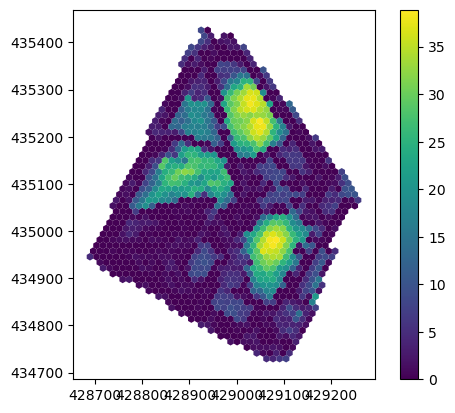

In [14]:
results_2[0].plot(column="visibility_pct", cmap="viridis", legend=True)

<Axes: >

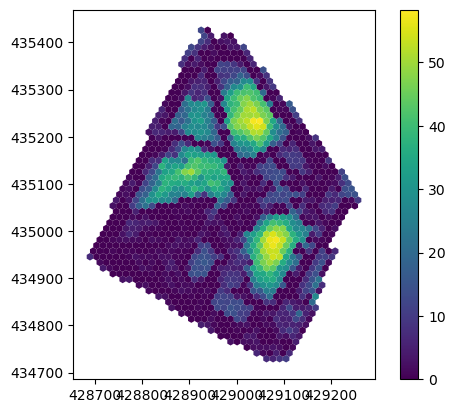

In [15]:
results_3[0].plot(column="visibility_pct", cmap="viridis", legend=True)

In [16]:
results_2[1]

,geometry,max_height,mean_height,std_height,count_pixels,percent_cover,percent_above_0.1m,low_level_<0.5,mid_level_0.5-2,tall_2+
13,"POLYGON ((429070.155 434733.602, 429063.227 43...",6.245995,0.451428,1.399728,168,0.037940,13.690476,0.595238,4.166667,8.333333
14,"POLYGON ((429084.012 434733.602, 429077.083 43...",9.672997,1.178845,2.664034,167,0.037715,22.155689,1.796407,3.592814,16.167665
15,"POLYGON ((429097.868 434733.602, 429090.94 434...",9.517998,0.528018,1.891642,167,0.037715,8.982036,0.000000,0.598802,7.784431
16,"POLYGON ((429111.724 434733.602, 429104.796 43...",5.079994,0.084198,0.447182,167,0.037715,8.383234,1.796407,4.790419,0.598802
23,"POLYGON ((429049.371 434745.602, 429042.442 43...",8.755005,0.404082,1.425736,159,0.035908,13.207547,1.886792,2.515723,7.547170
...,...,...,...,...,...,...,...,...,...,...
1630,"POLYGON ((428952.376 435417.602, 428945.447 43...",12.541000,3.398723,4.182738,159,0.035908,59.119497,6.289308,8.176101,42.138365
1632,"POLYGON ((428980.088 435417.602, 428973.16 435...",4.216995,0.571072,1.052269,167,0.037715,38.922156,9.580838,16.167665,10.179641
1633,"POLYGON ((428993.945 435417.602, 428987.017 43...",11.976006,2.891036,3.978586,168,0.037940,52.976190,1.785714,14.880952,35.714286
1637,"POLYGON ((428931.591 435429.602, 428924.663 43...",10.152000,0.558423,1.930925,168,0.037940,10.119048,0.000000,1.785714,8.333333


In [20]:
results_2[0].visibility_pct.describe()

count    1408.000000
mean        7.502043
std        10.231865
min         0.000000
25%         0.000000
50%         2.210012
75%        10.959031
max        38.888889
Name: visibility_pct, dtype: float64

In [22]:
results_3[0].visibility_pct.describe()

count    1408.000000
mean       10.647775
std        14.382606
min         0.000000
25%         0.000000
50%         3.333333
75%        15.000000
max        58.333333
Name: visibility_pct, dtype: float64

<Axes: >

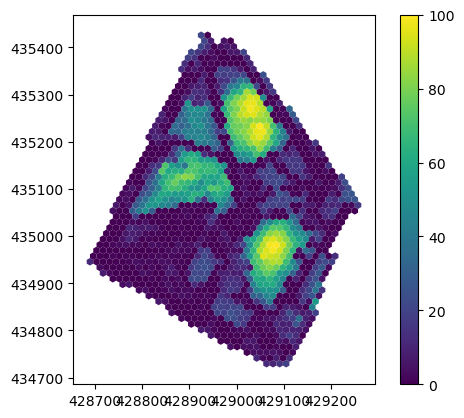

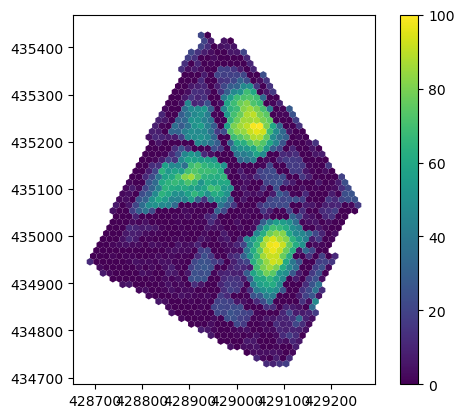

In [26]:
# scale  results_2[0].visibility_pct and results_3[0].visibility_pct so that I can better compare relative differences

# Scale results_2 to 0-100 range
min_2 = results_2[0]['visibility_pct'].min()
max_2 = results_2[0]['visibility_pct'].max()
results_2[0]['visibility_pct_scaled'] = ((results_2[0]['visibility_pct'] - min_2) / (max_2 - min_2)) * 100

# Scale results_3 to 0-100 range
min_3 = results_3[0]['visibility_pct'].min()
max_3 = results_3[0]['visibility_pct'].max()
results_3[0]['visibility_pct_scaled'] = ((results_3[0]['visibility_pct'] - min_3) / (max_3 - min_3)) * 100

# Plot with the scaled columns
results_2[0].plot(column="visibility_pct_scaled", cmap="viridis", legend=True, vmin=0, vmax=100)
results_3[0].plot(column="visibility_pct_scaled", cmap="viridis", legend=True, vmin=0, vmax=100)

<Axes: >

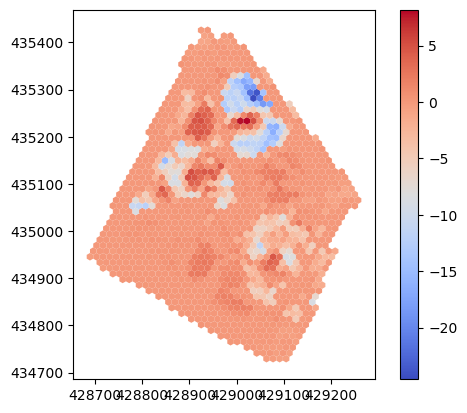

In [29]:
results_2[0]['comp'] = results_3[0]['visibility_pct_scaled'] - results_2[0]['visibility_pct_scaled']
results_2[0].plot(column='comp', cmap="coolwarm", legend=True)

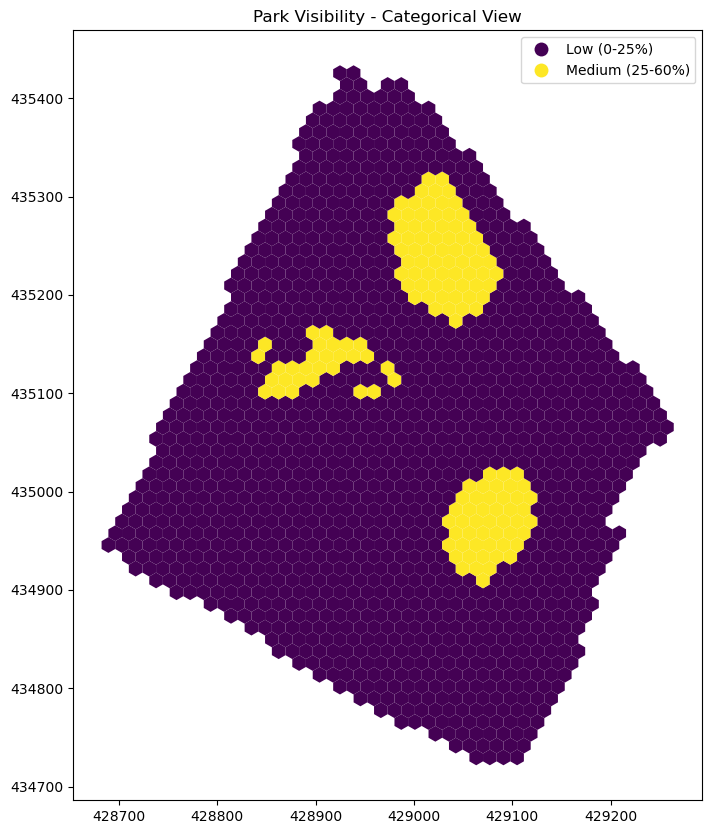

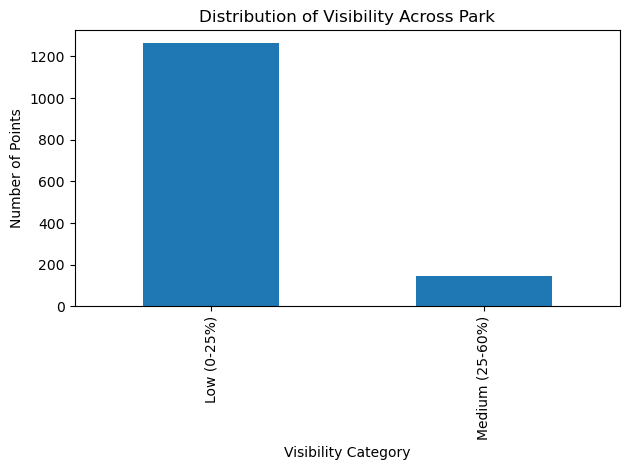

In [33]:
# Create visibility categories
def categorize_visibility(value):
    if value < 25:
        return 'Low (0-25%)'
    elif value < 60:
        return 'Medium (25-60%)'
    elif value < 80:
        return 'High (60-80%)'
    else:
        return 'Excellent (80%+)'

results_2[0]['visibility_category'] = results_2[0]['visibility_pct'].apply(categorize_visibility)

# Create a mapping for colors
category_colors = {
    'Low (0-25%)': '#440154',      # Dark purple
    'Medium (25-60%)': '#31688e',  # Blue
    'High (60-80%)': '#35b779',    # Green
    'Excellent (80%+)': '#fde724'  # Yellow
}

# Plot with categorical colors
fig, ax = plt.subplots(figsize=(12, 10))
results_2[0].plot(column='visibility_category', 
                  categorical=True,
                  cmap='viridis',
                  legend=True,
                  ax=ax)
ax.set_title('Park Visibility - Categorical View')
plt.show()

# Alternatively, to show the distribution:
results_2[0]['visibility_category'].value_counts().plot(kind='bar')
plt.xlabel('Visibility Category')
plt.ylabel('Number of Points')
plt.title('Distribution of Visibility Across Park')
plt.tight_layout()
plt.show()